### 2D Burgers Equations

Here are the 2D continuous Burgers Equation for horizontal velocity, u, and vertical velocity, v, where vc is the constant defining kinematic viscosity. Note the second term of the v equation is mutiplies by u(t, x, y), not v(t, x, y). 

In [9]:
from sympy import Eq, solve, symbols, Function, lambdify, diff

u, v = symbols('u v', cls=Function)
x, y, t, dt, dx, dy, vc = symbols('x y t dt dx dy vc')

continuous = Eq(diff(u(t, x, y), t) + u(t, x, y)*(diff(u(t, x, y), x) + diff(u(t, x, y), y)), vc*(diff(u(t, x, y), x, x) + diff(u(t, x, y), y, y)))
continuous

Eq((Derivative(u(t, x, y), x) + Derivative(u(t, x, y), y))*u(t, x, y) + Derivative(u(t, x, y), t), vc*(Derivative(u(t, x, y), (x, 2)) + Derivative(u(t, x, y), (y, 2))))

In [ ]:
continuous_v = Eq(diff(v(t, x, y), t) + v(t, x, y)*diff(v(t, x, y), x) + u(t, x, y)*diff(v(t, x, y), y), vc*(diff(v(t, x, y), x, x) + diff(u(t, x, y), y, y)))
continuous_v

Discretise the first order derivatives with the definition of a derivative - see 2d-convection.ipynb - and the second order derivatives qith the taylor expansion - see 2d-diffusion.ipynb.

In [2]:
discrete = Eq((u(t+1, x, y) - u(t, x, y))/dt + u(t, x, y)*((u(t, x, y) - u(t, x-1, y))/dx + (u(t, x, y) - u(t, x, y-1))/dy), 
vc*((-2*u(t, x, y) + u(t, x-1, y) + u(t, x+1, y))/(dx*dx) + (-2*u(t, x, y) + u(t, x, y-1) + u(t, x, y+1))/(dy*dy)))
discrete

Eq(((u(t, x, y) - u(t, x, y - 1))/dy + (u(t, x, y) - u(t, x - 1, y))/dx)*u(t, x, y) + (-u(t, x, y) + u(t + 1, x, y))/dt, vc*((-2*u(t, x, y) + u(t, x, y - 1) + u(t, x, y + 1))/dy**2 + (-2*u(t, x, y) + u(t, x - 1, y) + u(t, x + 1, y))/dx**2))

Rearrange to solve for u(t+1, x, y) and hence advance time.

In [3]:
solution = solve(discrete, u(t+1, x, y))[0]
solution

(dt*dx**2*dy*(-u(t, x, y) + u(t, x, y - 1))*u(t, x, y) + dt*dx**2*vc*(-2*u(t, x, y) + u(t, x, y - 1) + u(t, x, y + 1)) + dt*dx*dy**2*(-u(t, x, y) + u(t, x - 1, y))*u(t, x, y) + dt*dy**2*vc*(-2*u(t, x, y) + u(t, x - 1, y) + u(t, x + 1, y)) + dx**2*dy**2*u(t, x, y))/(dx**2*dy**2)

Perform the same process for the v equation and simplify both equations.

In [4]:
simplified_u = Eq(u(t+1, x, y), dt/dy*(u(t, x, y-1) - u(t, x, y))*u(t, x, y) + 
dt/dy**2*vc*(u(t, x, y-1) + u(t, x, y+1) - 2*u(t, x, y)) +
dt/dx*(u(t, x-1, y) - u(t, x, y))*u(t, x, y) + 
dt/dx**2*vc*(u(t, x+1, y) + u(t, x+1, y) - 2*u(t, x, y)) + 
u(t, x, y))

simplified_u

Eq(u(t + 1, x, y), dt*(-u(t, x, y) + u(t, x, y - 1))*u(t, x, y)/dy + dt*vc*(-2*u(t, x, y) + u(t, x, y - 1) + u(t, x, y + 1))/dy**2 + dt*(-u(t, x, y) + u(t, x - 1, y))*u(t, x, y)/dx + dt*vc*(-2*u(t, x, y) + 2*u(t, x + 1, y))/dx**2 + u(t, x, y))

In [5]:
simplified_v = Eq(v(t+1, x, y), dt/dy*(v(t, x, y-1) - v(t, x, y))*v(t, x, y) + 
dt/dy**2*vc*(v(t, x, y-1) + v(t, x, y+1) - 2*v(t, x, y)) +
dt/dx*(v(t, x-1, y) - v(t, x, y))*u(t, x, y) + 
dt/dx**2*vc*(v(t, x+1, y) + v(t, x+1, y) - 2*v(t, x, y)) + 
v(t, x, y))

simplified_v

Eq(v(t + 1, x, y), dt*(-v(t, x, y) + v(t, x, y - 1))*v(t, x, y)/dy + dt*vc*(-2*v(t, x, y) + v(t, x, y - 1) + v(t, x, y + 1))/dy**2 + dt*(-v(t, x, y) + v(t, x - 1, y))*u(t, x, y)/dx + dt*vc*(-2*v(t, x, y) + 2*v(t, x + 1, y))/dx**2 + v(t, x, y))

In [44]:
import numpy as np
import matplotlib.pyplot as plt

width = 30
height = 30
nu = width*height

dx = 1
dy = 1
dt = 0.08

def initial_conditions():
    u = np.ones(shape=(width, height))
    u[int(width/4):int(3*width/4), int(height/4):int(3*height/4)] = 2
    return u

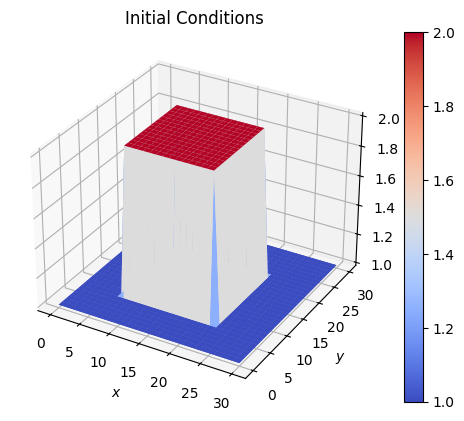

In [83]:
x = np.linspace(0, width, num=width)
y = np.linspace(0, height, num=height)
X, Y = np.meshgrid(x, y)

def plot(u, v, title=None):
    fig, ax = plt.subplots(subplot_kw={"projection":"3d"})
    su = ax.plot_surface(X, Y, u, cmap="coolwarm", linewidth=0)
    sv = ax.plot_surface(X, Y, v, cmap="coolwarm", linewidth=0)
    fig.colorbar(su)
    ax.set_title(title)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    plt.show()

plot(initial_conditions(), initial_conditions(), title="Initial Conditions")

$\displaystyle u{\left(t + 1,x,y \right)} = \frac{dt \left(- u{\left(t,x,y \right)} + u{\left(t,x,y - 1 \right)}\right) u{\left(t,x,y \right)}}{dy} + \frac{dt vc \left(- 2 u{\left(t,x,y \right)} + u{\left(t,x,y - 1 \right)} + u{\left(t,x,y + 1 \right)}\right)}{dy^{2}} + \frac{dt \left(- u{\left(t,x,y \right)} + u{\left(t,x - 1,y \right)}\right) u{\left(t,x,y \right)}}{dx} + \frac{dt vc \left(- 2 u{\left(t,x,y \right)} + 2 u{\left(t,x + 1,y \right)}\right)}{dx^{2}} + u{\left(t,x,y \right)}$

$\displaystyle v{\left(t + 1,x,y \right)} = \frac{dt \left(- v{\left(t,x,y \right)} + v{\left(t,x,y - 1 \right)}\right) v{\left(t,x,y \right)}}{dy} + \frac{dt vc \left(- 2 v{\left(t,x,y \right)} + v{\left(t,x,y - 1 \right)} + v{\left(t,x,y + 1 \right)}\right)}{dy^{2}} + \frac{dt \left(- v{\left(t,x,y \right)} + v{\left(t,x - 1,y \right)}\right) u{\left(t,x,y \right)}}{dx} + \frac{dt vc \left(- 2 v{\left(t,x,y \right)} + 2 v{\left(t,x + 1,y \right)}\right)}{dx^{2}} + v{\left(t,x,y \right)}$

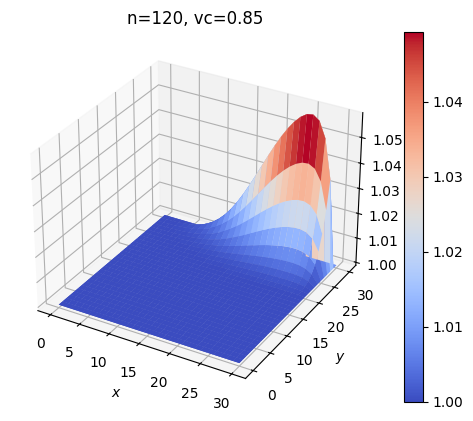

In [ ]:

def burgers(nt, vc):
    u = initial_conditions()
    v = initial_conditions()

    for n in range(nt+1):
        un = u.copy()
        vn = v.copy()

        u[1:-1, 1:-1] = ((dt/dy)*(un[1:-1, 0:-2] - un[1:-1, 1:-1])*un[1:-1, 1:-1]
        + (dt/dx)*(un[0:-2, 1:-1] - un[1:-1, 1:-1])*un[1:-1, 1:-1]
        + (dt/(dy**2))*vc*(un[1:-1, 0:-2] + un[1:-1, 2:] - 2*un[1:-1, 1:-1])
        + (dt/(dx**2))*vc*(2*un[0:-2, 1:-1] - 2*un[1:-1, 1:-1])
        + un[1:-1, 1:-1])

        v[1:-1, 1:-1] = ((dt/dy)*(vn[1:-1, 0:-2] - vn[1:-1, 1:-1])*vn[1:-1, 1:-1]
        + (dt/dx)*(vn[0:-2, 1:-1] - un[1:-1, 1:-1])*un[1:-1, 1:-1]
        + (dt/(dy**2))*vc*(vn[1:-1, 0:-2] + vn[1:-1, 2:] - 2*vn[1:-1, 1:-1])
        + (dt/(dx**2))*vc*(2*vn[0:-2, 1:-1] - 2*vn[1:-1, 1:-1])
        + vn[1:-1, 1:-1])

    plot(u, v, title=f"n={n}, vc={vc}")

burgers(120, 0.75)

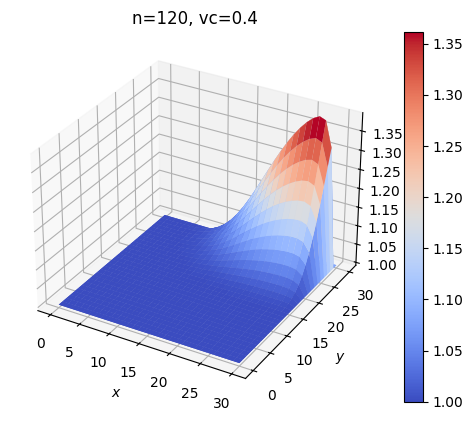

In [85]:
burgers(120, vc=0.4)

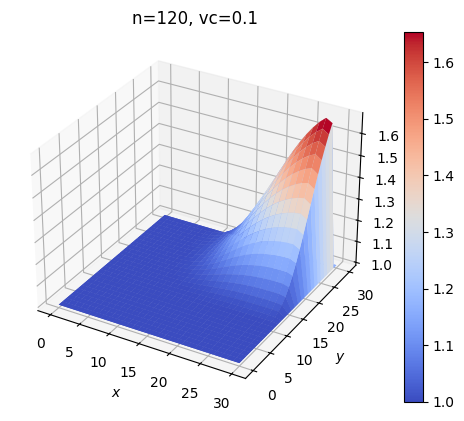

In [86]:
burgers(120, vc=0.1)